# **EXPERIMENT-11**  -Student Grade Card
**AIM:**
To construct and analyze a Bayesian Network using the pgmpy library for probabilistic inference and to compute conditional probabilities using the Variable Elimination algorithm.

**Bayesian Network:**
* A Bayesian Network (BN) is a probabilistic graphical model.
* It represents random variables as nodes and dependencies as directed edges.
* The graph must be a Directed Acyclic Graph (DAG).
* Each node contains a Conditional Probability Distribution (CPD) that defines the probability of that variable given its parent variables.

**Key Concepts:**
Random Variables

Each node in the Bayesian Network represents a random variable.
Example: Difficulty, Intelligence, Grade, SAT, Letter.

* Conditional Probability:

    The probability of a variable given its parents is written as:
          $$𝑃(𝑋𝑖/𝑃𝑎𝑟𝑒𝑛𝑡𝑠(𝑋𝑖))$$
* Joint Probability Formula:

   * For random variables $X_1, X_2, ..., X_n$:

   $$P(X_1, X_2, ..., X_n) =\prod_{i=1}^{n} P(X_i \mid Parents(X_i))$$

   * This means each variable depends only on its parent nodes.The probability of the entire system can be computed by multiplying all conditional probabilities.

**Steps in Bayesian Network:**
 1. Define the network structure (DAG).
 2. Define Conditional Probability Distributions (CPDs).
 3. Add CPDs to the model.
 4. Validate the model.
 5. Display CPDs.
 6. Perform probabilistic inference.

**Advantages:**
 * Handles uncertainty in data.
 * Useful for probabilistic reasoning.
 * Can model complex dependencies between variables.

**Disadvantages:**
 * Requires accurate probability values.
 * Can become computationally expensive for large networks.

In [ ]:
!pip install pgmpy #This installs the pgmpy library, which provides tools for creating Bayesian Networks, Markov Models, and probabilistic inference algorithms.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 37.1 MB/s eta 0:00:00


**pgmpy–** library used to build probabilistic graphical models like Bayesian Networks.

**DiscreteBayesianNetwork–** class used to construct Bayesian Networks with discrete variables.

**TabularCPD–** used to define conditional probability tables.

**VariableElimination–** inference algorithm used to compute probabilities.

**NetworkX–** used to represent the network as a graph.

**Matplotlib–** used to visualize the network.

In [ ]:
import pandas as pd
import numpy as np
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt

**Define the Network Structure:**
* This step defines the structure of the Bayesian Network.
* The directed edges represent dependencies:
* Difficulty → Grade
  * Course difficulty affects the student's grade.
* Intelligence → Grade
  * Student intelligence also affects the grade.
* Intelligence → SAT
  * SAT score depends on intelligence.
* Grade → Letter
  * Recommendation letter depends on the student's grade.

This structure forms a Directed Acyclic Graph (DAG).

In [ ]:
model = DiscreteBayesianNetwork([
    ('Difficulty', 'Grade'),('Intelligence', 'Grade'),
    ('Intelligence', 'SAT'),('Grade', 'Letter')
])

**Visualize the Network:**
* This code visualizes the Bayesian Network.
  * DiGraph() creates a directed graph.
* spring_layout() arranges nodes automatically.
  * nx.draw() draws nodes and arrows showing dependencies.
The arrows indicate cause → effect relationships between variables.
* G: This is the NetworkX graph object that you want to visualize.
* pos: This is a dictionary that specifies the position of each node in the graph. The keys are the nodes, and the values are their coordinates (e.g., (x, y) tuples). This parameter is necessary to ensure a consistent layout when adding further elements like edge labels.
* with_labels=True: This parameter tells the function to draw labels on the nodes. By default, the node labels will be their names (or identifiers).
* node_size=3000: This sets the size of the nodes in the graph (in points, by default).
* node_color="lightblue": This specifies the color of the nodes as "lightblue".
* font_size=10: This sets the font size for the node labels to 10 points.
* font_weight="bold": This makes the node labels appear in bold text.
arrows=True: This parameter is relevant if G is a directed graph (DiGraph or MultiDiGraph). It ensures that the edges are displayed as arrows, indicating the direction of the connection between nodes.

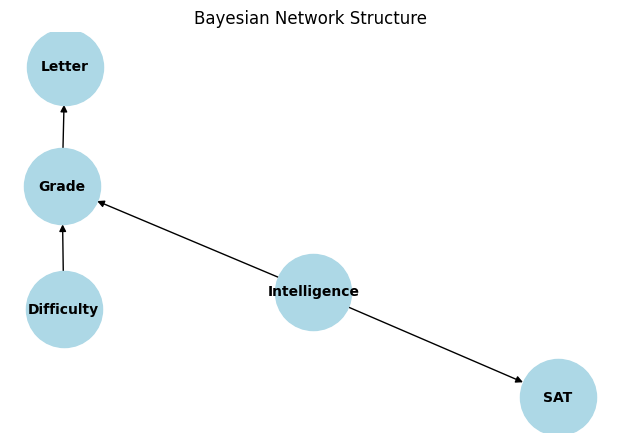

In [ ]:
plt.figure(figsize=(6,4))
G = nx.DiGraph(model.edges())
pos = nx.spring_layout(G)
nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=3000,
    node_color="lightblue",
    font_size=10,
    font_weight="bold",
    arrows=True
)
plt.title("Bayesian Network Structure")
plt.show()

**Define CPD for Difficulty:** This defines the probability distribution for Difficulty.
* The variable has 2 states.
* Probability values:
  * Easy → 0.6
  * Hard → 0.4
  
Since Difficulty has no parent variables, this is a prior probability distribution.

In [ ]:
cpd_difficulty = TabularCPD('Difficulty', 2, [[0.6],[0.4]])

**Define CPD for Intelligence:**
This defines the probability distribution of Intelligence.
* High Intelligence → 0.7
* Low Intelligence → 0.3

This is also a root node with no parent variables.

In [ ]:
cpd_intelligence = TabularCPD('Intelligence', 2, [[0.7],[0.3]])

**Define CPD for Grade:**
This CPD defines the probability of Grade based on: **Difficulty** & **Intelligence**


* 'Grade', 3: The variable is 'Grade', which has 3 possible outcomes (e.g., A, B, C or 0, 1, 2).
* [[0.3...]] (Values): These are the probabilities arranged in a table. Rows represent Grade outcomes (Row 0=Grade A, 1=B, 2=C), and columns represent the 4 possible combinations of Difficulty and Intelligence (
 combinations).
* evidence=['Difficulty','Intelligence']: The grade depends on these two factors.
* evidence_card=[2,2]: Each of these factors has 2 possible states (e.g., Diff: Easy/Hard, Intel: Low/High).
* The probability table shows how grade changes depending on different combinations of difficulty and intelligence.

**How to read the table:**
Each column sums to 1.0 or 100%
. For example, the first column [0.3, 0.4, 0.3] means if the course is Easy and Intelligence is Low, there is a 30% chance of an A, 40% chance of a B, and 30% chance of a C.  
Here is how your data is actually mapped:

                      Scenario 1	  Scenario 2	 Scenario 3  	Scenario 4
     Row 1 (Grade A)  	0.3	         0.05       	 0.9	           0.5
     Row 2 (Grade B)	0.4          0.25	         0.08	           0.3
     Row 3 (Grade C)	0.3	         0.7	         0.02	           0.2
     Total (Sum)	    1.0	         1.0	         1.0	           1.0

In [ ]:
cpd_grade = TabularCPD(
    'Grade', 3,
    [[0.3,0.05,0.9,0.5],
     [0.4,0.25,0.08,0.3],
     [0.3,0.7,0.02,0.2]],
    evidence=['Difficulty','Intelligence'],
    evidence_card=[2,2]
)

**Define CPD for SAT:**
This CPD defines the probability of SAT score.
* SAT depends on Intelligence.

Students with high intelligence have higher probability of good SAT scores.

The Probability Breakdown:

Looking at your values [[0.95, 0.2], [0.05, 0.8]], here is how to read the outcomes:
* Scenario 1: Low Intelligence (Column 1)
  * 95% chance (0.95) of a Low SAT score.
  * 5% chance (0.05) of a High SAT score (perhaps they got lucky!).
* Scenario 2: High Intelligence (Column 2)
  * 20% chance (0.2) of a Low SAT score (perhaps they had a bad day).
  * 80% chance (0.8) of a High SAT score.

In [ ]:
cpd_sat = TabularCPD(
    'SAT',2,
    [[0.95,0.2],
     [0.05,0.8]],
    evidence=['Intelligence'],
    evidence_card=[2]
)

**Define CPD for Letter:**
This CPD defines the probability of receiving a Recommendation Letter.
* Letter depends on Grade.

Students with better grades have higher chances of receiving recommendation letters.

**The Column Map:**
The columns follow the states of the Grade variable in order (0=A, 1=B, 2=C):

                        Column 1 (Grade A)	Column 2 (Grade B)	Column 3 (Grade C)
      Row 1 (Bad Letter)	0.1 (10%)	        0.4 (40%)          	0.99 (99%)
      Row 2 (Good Letter)	0.9 (90%)	        0.6 (60%)	         0.01 (1%)
**The Logic Breakdown:**
  * If the student gets an A (Col 1): There is a 90% chance they get a great letter and only a 10% chance of a bad one.
  * If the student gets a B (Col 2): It’s a bit more uncertain, but still leans toward a good letter (60%).
  * If the student gets a C (Col 3): It is almost certain (99%) they will receive a bad recommendation letter.


In [ ]:
cpd_letter = TabularCPD(
    'Letter',2,
    [[0.1,0.4,0.99],
     [0.9,0.6,0.01]],
    evidence=['Grade'],
    evidence_card=[3]
)

**Add CPDs to the Model:**
This step attaches all defined CPDs to the Bayesian Network model.
Now the model contains both:
* Structure (graph)
* Probability distributions

In [ ]:
model.add_cpds(
    cpd_difficulty,
    cpd_intelligence,
    cpd_grade,
    cpd_sat,
    cpd_letter
)

**Validate the Model:**

The check_model() function verifies whether:
* Every node has a CPD
* CPDs match the network structure
* Probabilities sum to 1

If everything is correct, the output will be True.

In [ ]:
print("Model Valid:", model.check_model())

Model Valid: True


**Display CPDs:**
This code prints all CPDs defined in the model so that we can verify the probability tables for each variable.

Column 2: Difficulty(0) + Intelligence(1) — (Hidden by ...)

Column 3: Difficulty(1) + Intelligence(0) — (Hidden by ...)


In [ ]:
for cpd in model.get_cpds():
    print(cpd)

+---------------+-----+
| Difficulty(0) | 0.6 |
+---------------+-----+
| Difficulty(1) | 0.4 |
+---------------+-----+
+-----------------+-----+
| Intelligence(0) | 0.7 |
+-----------------+-----+
| Intelligence(1) | 0.3 |
+-----------------+-----+
+--------------+-----------------+-----+-----------------+
| Difficulty   | Difficulty(0)   | ... | Difficulty(1)   |
+--------------+-----------------+-----+-----------------+
| Intelligence | Intelligence(0) | ... | Intelligence(1) |
+--------------+-----------------+-----+-----------------+
| Grade(0)     | 0.3             | ... | 0.5             |
+--------------+-----------------+-----+-----------------+
| Grade(1)     | 0.4             | ... | 0.3             |
+--------------+-----------------+-----+-----------------+
| Grade(2)     | 0.3             | ... | 0.2             |
+--------------+-----------------+-----+-----------------+
+--------------+-----------------+-----------------+
| Intelligence | Intelligence(0) | Intelligence(

**Perform Probabilistic Inference:**

This creates an inference object using the Variable Elimination algorithm.
* Variable Elimination works by:
   * eliminating irrelevant variables
   * computing required probabilities efficiently.

In [ ]:
inference = VariableElimination(model)

**Query 1–Marginal Probability**

This query computes the marginal probability distribution of Grade without any evidence.
* It answers the question:

   “What is the probability of each grade overall?”

In [ ]:
print(inference.query(variables=['Grade']))

+----------+--------------+
| Grade    |   phi(Grade) |
+==========+==============+
| Grade(0) |       0.4470 |
+----------+--------------+
| Grade(1) |       0.2714 |
+----------+--------------+
| Grade(2) |       0.2816 |
+----------+--------------+


**Query 2 – Conditional Probability:**
This query computes the probability of Grade given Intelligence.
* It answers the question:

   “If we know the student is intelligent, what is the probability of each grade?”

In [ ]:
print(inference.query(
    variables=['Grade'],
    evidence={'Intelligence':1}
))

+----------+--------------+
| Grade    |   phi(Grade) |
+==========+==============+
| Grade(0) |       0.2300 |
+----------+--------------+
| Grade(1) |       0.2700 |
+----------+--------------+
| Grade(2) |       0.5000 |
+----------+--------------+


**Query 3 – Recommendation Letter Probability:**

This query computes the probability of getting a Recommendation Letter given the student's Grade.

In [ ]:
print(inference.query(
    variables=['Letter'],
    evidence={'Grade':0}
))

+-----------+---------------+
| Letter    |   phi(Letter) |
+===========+===============+
| Letter(0) |        0.1000 |
+-----------+---------------+
| Letter(1) |        0.9000 |
+-----------+---------------+


**Conclusion:**

In this experiment, a Bayesian Network was used to model relationships between course difficulty, student intelligence, grades, SAT scores, and recommendation letters. The model predicted the probability of different grades, analyzed how intelligence influences academic performance, and estimated the likelihood of receiving a recommendation letter based on the student's grade. This demonstrates how Bayesian Networks can perform probabilistic reasoning and support decision making under uncertainty.